# Imports

In [3]:
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from collections import deque

# Configuration

In [4]:
# Account
INITIAL_BALANCE = 10_000
RISK_PER_TRADE = 0.10
LEVERAGE = 1.0

# Costs
TAKER_FEE_RATE = 0.0010
SLIPPAGE_RATE = 0.0005
ONE_WAY_COST = TAKER_FEE_RATE + SLIPPAGE_RATE

# Data
BASE_URL = "https://data-api.binance.vision"
SYMBOL = "BTCUSDT"
BAR_SIZE = "1h"

# Data Window
START = "2015-07-01 00:00:00"
END   = "2026-08-01 00:00:00"

# Parameters
HORIZON = 36
THRESHOLD_MULTIPLIER = 1.0          # multiply round-trip cost
ALLOW_SHORTS = True

# Model Parameters
LR = 0.00350
MODEL_L2 = 0.425

# Parameters Study Grid
HORIZON_GRID = [35, 36, 37]
THRESHOLD_MULTIPLIER_GRID = [0.0, 1.0, 2.0]

# Hyperparameters Study Grid
LR_GRID = [0.00325, 0.00350, 0.00375]
MODEL_L2_GRID = [0.400, 0.425, 0.450]
#36	1.0	0.00350	0.425

# Data Loader

In [5]:
def load_data(symbol, start, end, interval, limit=1000):
    start_ms = int(pd.Timestamp(start, tz="UTC").timestamp() * 1000)
    end_ms = int(pd.Timestamp(end, tz="UTC").timestamp() * 1000)

    all_rows = []
    current_start = start_ms

    while current_start < end_ms:
        url = f"{BASE_URL}/api/v3/klines"
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": limit,
        }

        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        rows = r.json()

        if not rows:
            break

        all_rows.extend(rows)

        last_open_time = rows[-1][0]
        next_start = last_open_time + 1

        if next_start <= current_start:
            break

        current_start = next_start
        time.sleep(0.05)

    if not all_rows:
        raise ValueError("No data returned from Binance.")

    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
    ]

    df = pd.DataFrame(all_rows, columns=cols)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)

    numeric_cols = [
        "open", "high", "low", "close", "volume",
        "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"
    ]

    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.sort_values("open_time").drop_duplicates("open_time").reset_index(drop=True)
    df = df.set_index("open_time")

    return df

# Load Raw Data

In [6]:
raw_df = load_data(SYMBOL, START, END, BAR_SIZE)
raw_df.head()

,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
open_time,,,,,,,,,,,
2017-08-17 04:00:00+00:00,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999000+00:00,202366.138393,171,35.160503,150952.477943,0
2017-08-17 05:00:00+00:00,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999000+00:00,100304.823567,102,21.448071,92608.279728,0
2017-08-17 06:00:00+00:00,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999000+00:00,31282.312670,36,4.802861,20795.317224,0
2017-08-17 07:00:00+00:00,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999000+00:00,19241.058300,25,2.602292,11291.347015,0
2017-08-17 08:00:00+00:00,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999000+00:00,4239.503586,28,0.814655,3552.746817,0


# Data Checks

In [7]:
print(raw_df.shape)
print(raw_df.index.min(), "to", raw_df.index.max())
print(raw_df.isna().sum().sort_values(ascending=False).head(10))

(78373, 11)
2017-08-17 04:00:00+00:00 to 2026-08-01 00:00:00+00:00
open                            0
high                            0
low                             0
close                           0
volume                          0
close_time                      0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
taker_buy_quote_asset_volume    0
dtype: int64


# Feature Engineering

In [157]:
def build_features(raw_df, horizon=30):
    df = raw_df.copy()
    eps = 1e-12

    # Past multi-horizon log returns
    return_windows = [125, 150, 175, 200, 225, 250]
    for window in return_windows:
        df[f"ret_{window}"] = np.log(df["close"] / df["close"].shift(window))

    # Historical volatility of bar-by-bar log returns
    bar_ret = np.log(df["close"] / df["close"].shift(1))
    volatility_windows = [125, 150, 175, 200, 225, 250]
    for window in volatility_windows:
        df[f"volatility_{window}"] = bar_ret.rolling(
            window, min_periods=window
        ).std(ddof=0)

    # Relative volume: current volume divided by its trailing average
    volume_windows = [125, 150, 175, 200, 225, 250]
    for window in volume_windows:
        avg_volume = df["volume"].rolling(window, min_periods=window).mean()
        df[f"relative_volume_{window}"] = df["volume"] / (avg_volume + eps)

    # Distance from trailing high/low, expressed as a fraction of price
    price_windows = [125, 150, 175, 200, 225, 250]
    for window in price_windows:
        recent_high = df["high"].rolling(window, min_periods=window).max()
        recent_low = df["low"].rolling(window, min_periods=window).min()

        df[f"distance_from_high_{window}"] = df["close"] / (recent_high + eps) - 1
        df[f"distance_from_low_{window}"] = df["close"] / (recent_low + eps) - 1

    # Candle pressure
    candle_range = (df["high"] - df["low"]).clip(lower=eps)

    # Close location within the candle: -1 near the low, +1 near the high
    df["candle_close_pressure"] = (
        (2 * df["close"] - df["high"] - df["low"]) / candle_range
    )

    # Candle body direction/size normalized by the full candle range
    df["candle_body_pressure"] = (df["close"] - df["open"]) / candle_range

    # Taker-buy pressure, if the source data includes the taker-buy volume column
    if "taker_buy_base_asset_volume" in df.columns:
        df["taker_buy_pressure"] = (
            2 * df["taker_buy_base_asset_volume"] / (df["volume"] + eps) - 1
        )

    # Targets
    df["future_log_return_h"] = np.log(
        df["close"].shift(-horizon) / df["close"]
    )
    df["future_log_return_1"] = np.log(
        df["close"].shift(-1) / df["close"]
    )

    feature_cols = (
        [f"ret_{w}" for w in return_windows]
        + [f"volatility_{w}" for w in volatility_windows]
#        + [f"relative_volume_{w}" for w in volume_windows]
#        + [f"distance_from_high_{w}" for w in price_windows]
#        + [f"distance_from_low_{w}" for w in price_windows]
#        + ["candle_close_pressure", "candle_body_pressure"]
    )

#    if "taker_buy_pressure" in df.columns:
#        feature_cols.append("taker_buy_pressure")

    df = df.replace([np.inf, -np.inf], np.nan).dropna().copy()

    return df, feature_cols, "future_log_return_h", "future_log_return_1"

# Build Modeling Dataset

In [158]:
df, feature_cols, target_col, pnl_col = build_features(raw_df, HORIZON)

print("Rows:", len(df))
print("Features:", len(feature_cols))
print(feature_cols)
df[[target_col] + feature_cols].describe().T

Rows: 78087
Features: 12
['ret_125', 'ret_150', 'ret_175', 'ret_200', 'ret_225', 'ret_250', 'volatility_125', 'volatility_150', 'volatility_175', 'volatility_200', 'volatility_225', 'volatility_250']


,count,mean,std,min,25%,50%,75%,max
future_log_return_h,78087.0,0.001244,0.042924,-0.641896,-0.017134,0.001303,0.020349,0.303887
ret_125,78087.0,0.004365,0.080218,-0.765076,-0.033380,0.003544,0.044377,0.451863
ret_150,78087.0,0.005261,0.088439,-0.788206,-0.035934,0.003891,0.049073,0.489689
ret_175,78087.0,0.006146,0.096316,-0.791006,-0.039573,0.005042,0.052805,0.598987
ret_200,78087.0,0.007038,0.103324,-0.747531,-0.042377,0.005979,0.057794,0.570061
ret_225,78087.0,0.007922,0.109544,-0.750965,-0.045606,0.007097,0.062153,0.555237
ret_250,78087.0,0.008788,0.115662,-0.758010,-0.049389,0.007612,0.066680,0.604372
volatility_125,78087.0,0.006503,0.004050,0.001376,0.004026,0.005466,0.007574,0.040862
volatility_150,78087.0,0.006544,0.003996,0.001442,0.004079,0.005504,0.007605,0.037753
volatility_175,78087.0,0.006578,0.003951,0.001542,0.004129,0.005525,0.007616,0.035533


# Data Visualization

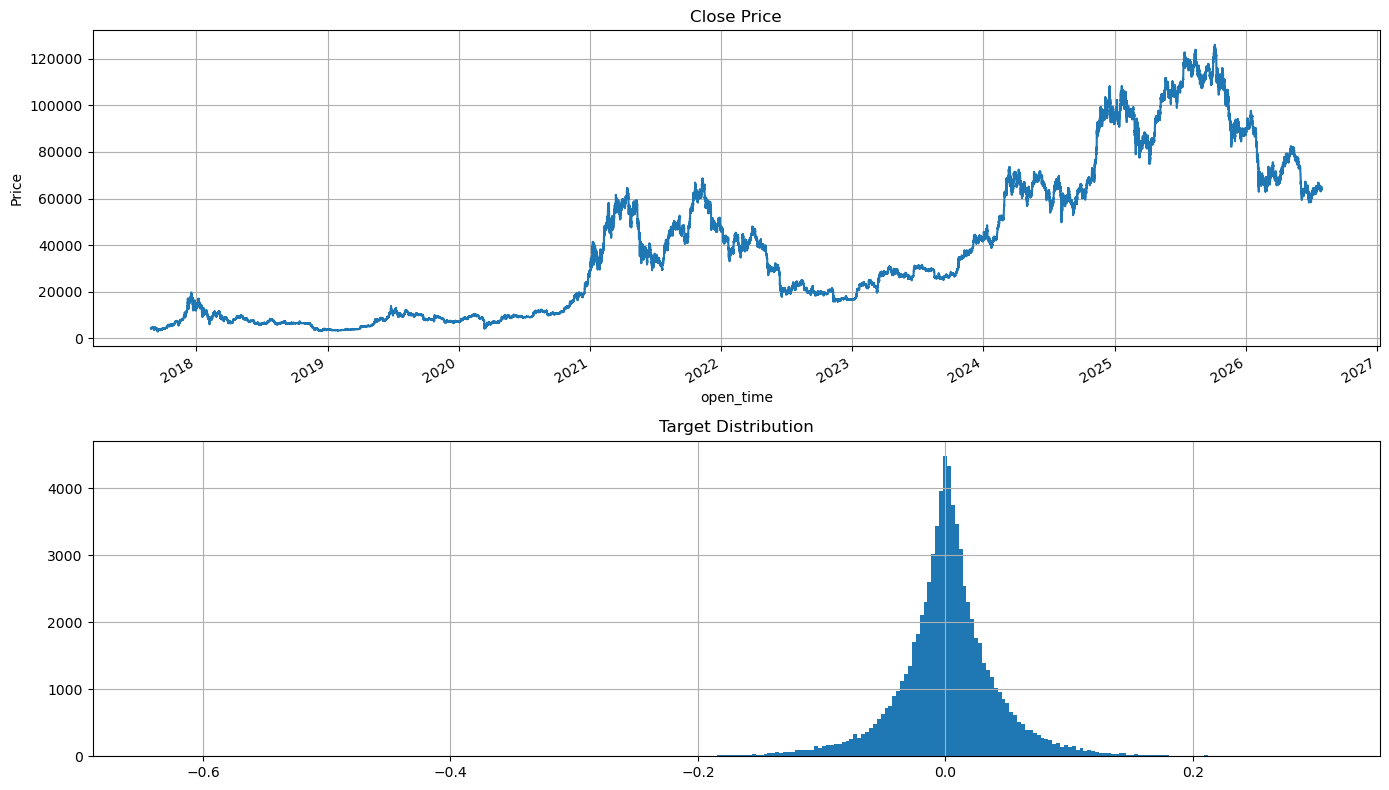

In [159]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

df["close"].plot(ax=ax[0], title="Close Price", grid=True)
df[target_col].hist(ax=ax[1], bins=300, grid=True)

ax[0].set_ylabel("Price")
ax[1].set_title("Target Distribution")
plt.tight_layout()
plt.show()

# Linear Regression Model

In [160]:
class LinearRegressionModel:
    def __init__(self, n_features, lr=0.001, model_l2=0.0):
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.lr = lr
        self.model_l2 = model_l2

    def predict(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)
        return float(np.dot(self.w, x) + self.b)

    def update(self, x, y):
        x = np.asarray(x, dtype=float).reshape(-1)
        y = float(y)

        pred = self.predict(x)
        err = pred - y

        self.w -= self.lr * (err * x + self.model_l2 * self.w)
        self.b -= self.lr * err

        return err

# Regression Metrics

In [161]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(y_true, y_pred)[0, 1]

    direction_acc = np.mean(np.sign(y_true) == np.sign(y_pred))

    return {
        "mse": float(mse),
        "mae": float(mae),
        "corr": float(corr) if not np.isnan(corr) else np.nan,
        "direction_acc": float(direction_acc),
    }


def max_drawdown(equity_curve):
    eq = np.asarray(equity_curve, dtype=float)
    peaks = np.maximum.accumulate(eq)
    drawdowns = (eq - peaks) / peaks
    return float(drawdowns.min())


def sharpe_ratio(returns, bars_per_year=24*365):
    rets = np.asarray(returns, dtype=float)
    if len(rets) < 2 or np.std(rets) == 0:
        return np.nan
    return float(np.sqrt(bars_per_year) * rets.mean() / rets.std())

# Trading Rule

In [162]:
def prediction_to_position(pred, threshold, allow_shorts=True):
    threshold = abs(threshold)
    if pred > threshold:
        return 1
    elif allow_shorts and pred < -threshold:
        return -1
    else:
        return 0

# Walk-Forward Evaluation

In [163]:
def walk_forward_simulation(
    df,
    feature_cols,
    target_col,           # e.g. future_log_return_h
    pnl_return_col,       # e.g. future_log_return_1
    horizon=30,
    lr=0.01,
    model_l2=0.0001,
    threshold_multiplier=1.25,
    allow_shorts=True,
    initial_balance=10_000.0
):
    threshold = threshold_multiplier * ONE_WAY_COST

    X = df[feature_cols].to_numpy()
    y_train = df[target_col].to_numpy()
    y_pnl = df[pnl_return_col].to_numpy()

    model = LinearRegressionModel(
        n_features=len(feature_cols),
        lr=lr,
        model_l2=model_l2
    )

    preds = []
    positions = []
    pnl_dollars = []
    pnl_pct = []
    equity_curve = [initial_balance]

    prev_position = 0
    pending_updates = deque()
    seen_samples = 0

    for i in range(len(df)):
        # 1) update model only with samples whose horizon outcome is now known
        while pending_updates and pending_updates[0][0] <= i:
            _, x_ready, y_ready = pending_updates.popleft()
            model.update(x_ready, y_ready)
            seen_samples += 1

        x_i = X[i]
        train_target_i = y_train[i]
        pnl_logret_i = y_pnl[i]

        # 2) predict current horizon return
        pred = model.predict(x_i)
        pred = float(np.clip(pred, -0.2, 0.2))

        position = prediction_to_position(
            pred,
            threshold,
            allow_shorts=allow_shorts
        )

        # 3) mark-to-market using next-bar realized return
        simple_return_1 = np.exp(pnl_logret_i) - 1.0

        position_size = equity_curve[-1] * LEVERAGE * RISK_PER_TRADE
        turnover = abs(position - prev_position)

        costs = ONE_WAY_COST * turnover * position_size
        gross_pnl = position * simple_return_1 * position_size
        net_pnl = gross_pnl - costs

        new_equity = equity_curve[-1] + net_pnl

        preds.append(pred)
        positions.append(position)
        pnl_dollars.append(net_pnl)
        pnl_pct.append(net_pnl / equity_curve[-1] if equity_curve[-1] != 0 else 0.0)
        equity_curve.append(new_equity)

        # 4) schedule current sample for update when label becomes known
        pending_updates.append((i + horizon, x_i.copy(), train_target_i))

        prev_position = position

    result = df.copy()
    result["prediction"] = preds
    result["position"] = positions
    result["strategy_pnl"] = pnl_dollars
    result["strategy_return"] = pnl_pct
    result["equity"] = equity_curve[1:]

    pred_metrics = regression_metrics(result[target_col], result["prediction"])

    prev_pos = result["position"].shift(1).fillna(0)
    trade_count = int((result["position"] != prev_pos).sum())
    long_count = int(((result["position"] == 1) & (prev_pos != 1)).sum())
    short_count = int(((result["position"] == -1) & (prev_pos != -1)).sum())
    flat_count = int(((result["position"] == 0) & (prev_pos != 0)).sum())

    trading_metrics = {
        "final_equity": float(result["equity"].iloc[-1]),
        "total_return": float(result["equity"].iloc[-1] / initial_balance - 1.0),
        "sharpe": sharpe_ratio(result["strategy_return"]),
        "max_drawdown": max_drawdown(result["equity"]),
        "trade_count": trade_count,
        "long_count": long_count,
        "short_count": short_count,
        "flat_count": flat_count,
        "avg_bar_return": float(result["strategy_return"].mean()),
    }

    return result, pred_metrics, trading_metrics

# Baseline Run

In [164]:
baseline_result, baseline_pred_metrics, baseline_trading_metrics = walk_forward_simulation(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    pnl_return_col=pnl_col,
    horizon=HORIZON,
    lr=LR,
    model_l2=MODEL_L2,
    threshold_multiplier=THRESHOLD_MULTIPLIER,
    allow_shorts=ALLOW_SHORTS,
    initial_balance=INITIAL_BALANCE
)

print("Prediction Metrics")
print(pd.Series(baseline_pred_metrics))

print("\nTrading Metrics")
print(pd.Series(baseline_trading_metrics))

Prediction Metrics
mse              0.001933
mae              0.029780
corr             0.033593
direction_acc    0.516936
dtype: float64

Trading Metrics
final_equity      16356.453930
total_return          0.635645
sharpe                0.832683
max_drawdown         -0.078955
trade_count         692.000000
long_count          174.000000
short_count         172.000000
flat_count          346.000000
avg_bar_return        0.000007
dtype: float64


# Plot Equity Curve

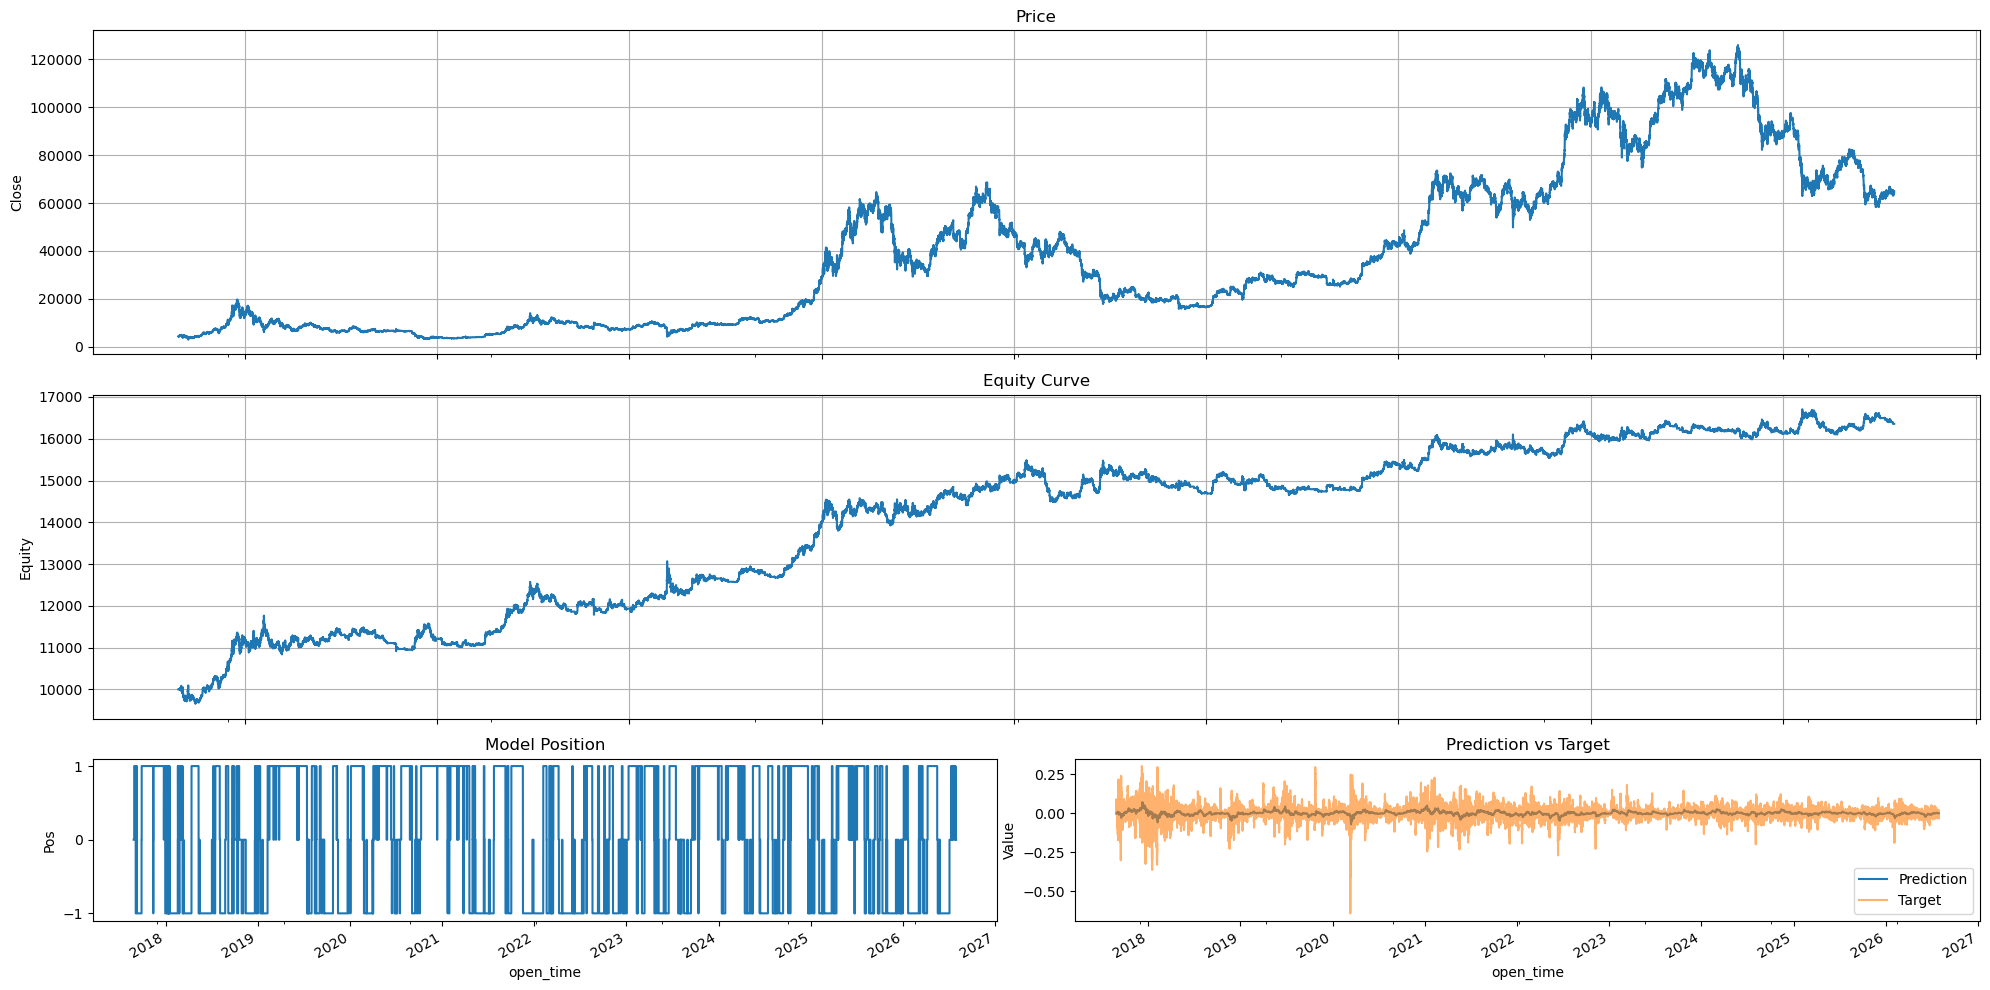

In [165]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1])

ax_price = fig.add_subplot(gs[0, :])
ax_equity = fig.add_subplot(gs[1, :], sharex=ax_price)
ax_pos = fig.add_subplot(gs[2, 0], sharex=ax_price)
ax_pred = fig.add_subplot(gs[2, 1], sharex=ax_price)

baseline_result["close"].plot(ax=ax_price, title="Price", grid=True)
baseline_result["equity"].plot(ax=ax_equity, title="Equity Curve", grid=True)
baseline_result["position"].plot(ax=ax_pos, title="Model Position", drawstyle="steps-post")

baseline_result["prediction"].plot(ax=ax_pred, label="Prediction", title="Prediction vs Target")
baseline_result[target_col].plot(ax=ax_pred, label="Target", alpha=0.6)

ax_price.set_ylabel("Close")
ax_equity.set_ylabel("Equity")
ax_pos.set_ylabel("Pos")
ax_pred.set_ylabel("Value")

ax_pos.set_yticks([-1, 0, 1])
ax_pred.legend()

plt.tight_layout()
plt.show()

# Baseline Feature Importance

In [166]:
X = df[feature_cols].astype(float).to_numpy()
y = df[target_col].astype(float).to_numpy()

# Train a fresh linear model using the same online-learning approach
importance_model = LinearRegressionModel(
    n_features=len(feature_cols),
    lr=LR,
    model_l2=MODEL_L2
)

for x_i, y_i in zip(X, y):
    importance_model.update(x_i, y_i)

# Signed and absolute feature importance
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": importance_model.w,
    "importance": np.abs(importance_model.w)
}).sort_values("importance", ascending=False)

display(feature_importance)

,feature,coefficient,importance
5,ret_250,-0.000867,0.000867
4,ret_225,-0.000745,0.000745
3,ret_200,-0.000468,0.000468
2,ret_175,-0.000386,0.000386
1,ret_150,-0.000384,0.000384
0,ret_125,-0.000314,0.000314
9,volatility_200,0.000022,0.000022
10,volatility_225,0.000022,0.000022
8,volatility_175,0.000021,0.000021
11,volatility_250,0.000020,0.000020


# Hyperparameter Study

In [70]:
hyperparameter_study = []

for horizon, threshold_multiplier, lr, model_l2 in product(
    HORIZON_GRID,
    THRESHOLD_MULTIPLIER_GRID,
    LR_GRID,
    MODEL_L2_GRID
):
    tmp_df, tmp_features, tmp_target, pnl_col = build_features(
        raw_df,
        horizon
    )

    _, pred_m, trade_m = walk_forward_simulation(
        tmp_df,
        tmp_features,
        tmp_target,
        pnl_col,
        horizon,
        lr,
        model_l2,
        threshold_multiplier,
        ALLOW_SHORTS,
        INITIAL_BALANCE
    )

    row = {
        "HORIZON": horizon,
        "THRESHOLD_MULTIPLIER": threshold_multiplier,
        "LR": lr,
        "MODEL_L2": model_l2,
        **pred_m,
        **trade_m,
    }
    hyperparameter_study.append(row)

hyperparameter_study_df = pd.DataFrame(hyperparameter_study).sort_values(
    ["sharpe", "total_return", "max_drawdown", "corr"],
    ascending=[False, False, True, False]
)

best_hyper_param = hyperparameter_study_df.iloc[0].to_dict()
hyperparameter_study_df.head(10)

,HORIZON,THRESHOLD_MULTIPLIER,LR,MODEL_L2,mse,mae,corr,direction_acc,final_equity,total_return,sharpe,max_drawdown,trade_count,long_count,short_count,flat_count,avg_bar_return
62,37,0.0,0.00375,0.450,0.002665,0.034282,-0.027569,0.500013,4926.165128,-0.507383,-1.067149,-0.559208,2681,1341,1340,0,-0.000009
72,37,2.0,0.00325,0.400,0.002660,0.034216,-0.029926,0.499962,4906.029063,-0.509397,-1.134481,-0.562535,4862,1281,1254,2327,-0.000009
60,37,0.0,0.00375,0.400,0.002683,0.034413,-0.028307,0.499552,4699.594861,-0.530041,-1.140349,-0.591760,2725,1363,1362,0,-0.000009
8,35,0.0,0.00375,0.450,0.002521,0.033235,-0.030459,0.500013,4691.579323,-0.530842,-1.143001,-0.589952,2767,1384,1383,0,-0.000009
59,37,0.0,0.00350,0.450,0.002654,0.034186,-0.028379,0.499718,4683.320445,-0.531668,-1.145839,-0.590732,2657,1329,1328,0,-0.000009
56,37,0.0,0.00325,0.450,0.002641,0.034083,-0.029215,0.500064,4674.293951,-0.532571,-1.148951,-0.592936,2568,1284,1284,0,-0.000009
63,37,1.0,0.00325,0.400,0.002660,0.034216,-0.029926,0.499962,4734.318383,-0.526568,-1.160749,-0.588834,4783,1303,1320,2160,-0.000009
7,35,0.0,0.00375,0.425,0.002528,0.033290,-0.030748,0.499936,4622.951737,-0.537705,-1.165847,-0.597127,2825,1413,1412,0,-0.000010
67,37,1.0,0.00350,0.425,0.002662,0.034249,-0.028737,0.499859,4715.236054,-0.528476,-1.166014,-0.583096,4872,1360,1321,2191,-0.000009
64,37,1.0,0.00325,0.425,0.002650,0.034147,-0.029563,0.500179,4715.537130,-0.528446,-1.167043,-0.591403,4767,1321,1299,2147,-0.000009


# Final Test

In [71]:
df_final, feature_cols_final, target_col_final, pnl_col = build_features(
    raw_df,
    int(best_hyper_param["HORIZON"])
)

final_result, final_pred_metrics, final_trading_metrics = walk_forward_simulation(
    df=df_final,
    feature_cols=feature_cols_final,
    target_col=target_col_final,
    pnl_return_col=pnl_col,
    horizon=best_hyper_param["HORIZON"],
    lr=best_hyper_param["LR"],
    model_l2=best_hyper_param["MODEL_L2"],
    threshold_multiplier=best_hyper_param["THRESHOLD_MULTIPLIER"],
    allow_shorts=ALLOW_SHORTS,
    initial_balance=INITIAL_BALANCE
)

print("Final Prediction Metrics")
print(pd.Series(final_pred_metrics))

print("\nFinal Trading Metrics")
print(pd.Series(final_trading_metrics))

Final Prediction Metrics
mse              0.002665
mae              0.034282
corr            -0.027569
direction_acc    0.500013
dtype: float64

Final Trading Metrics
final_equity      4926.165128
total_return        -0.507383
sharpe              -1.067149
max_drawdown        -0.559208
trade_count       2681.000000
long_count        1341.000000
short_count       1340.000000
flat_count           0.000000
avg_bar_return      -0.000009
dtype: float64


# Final Equity Plot

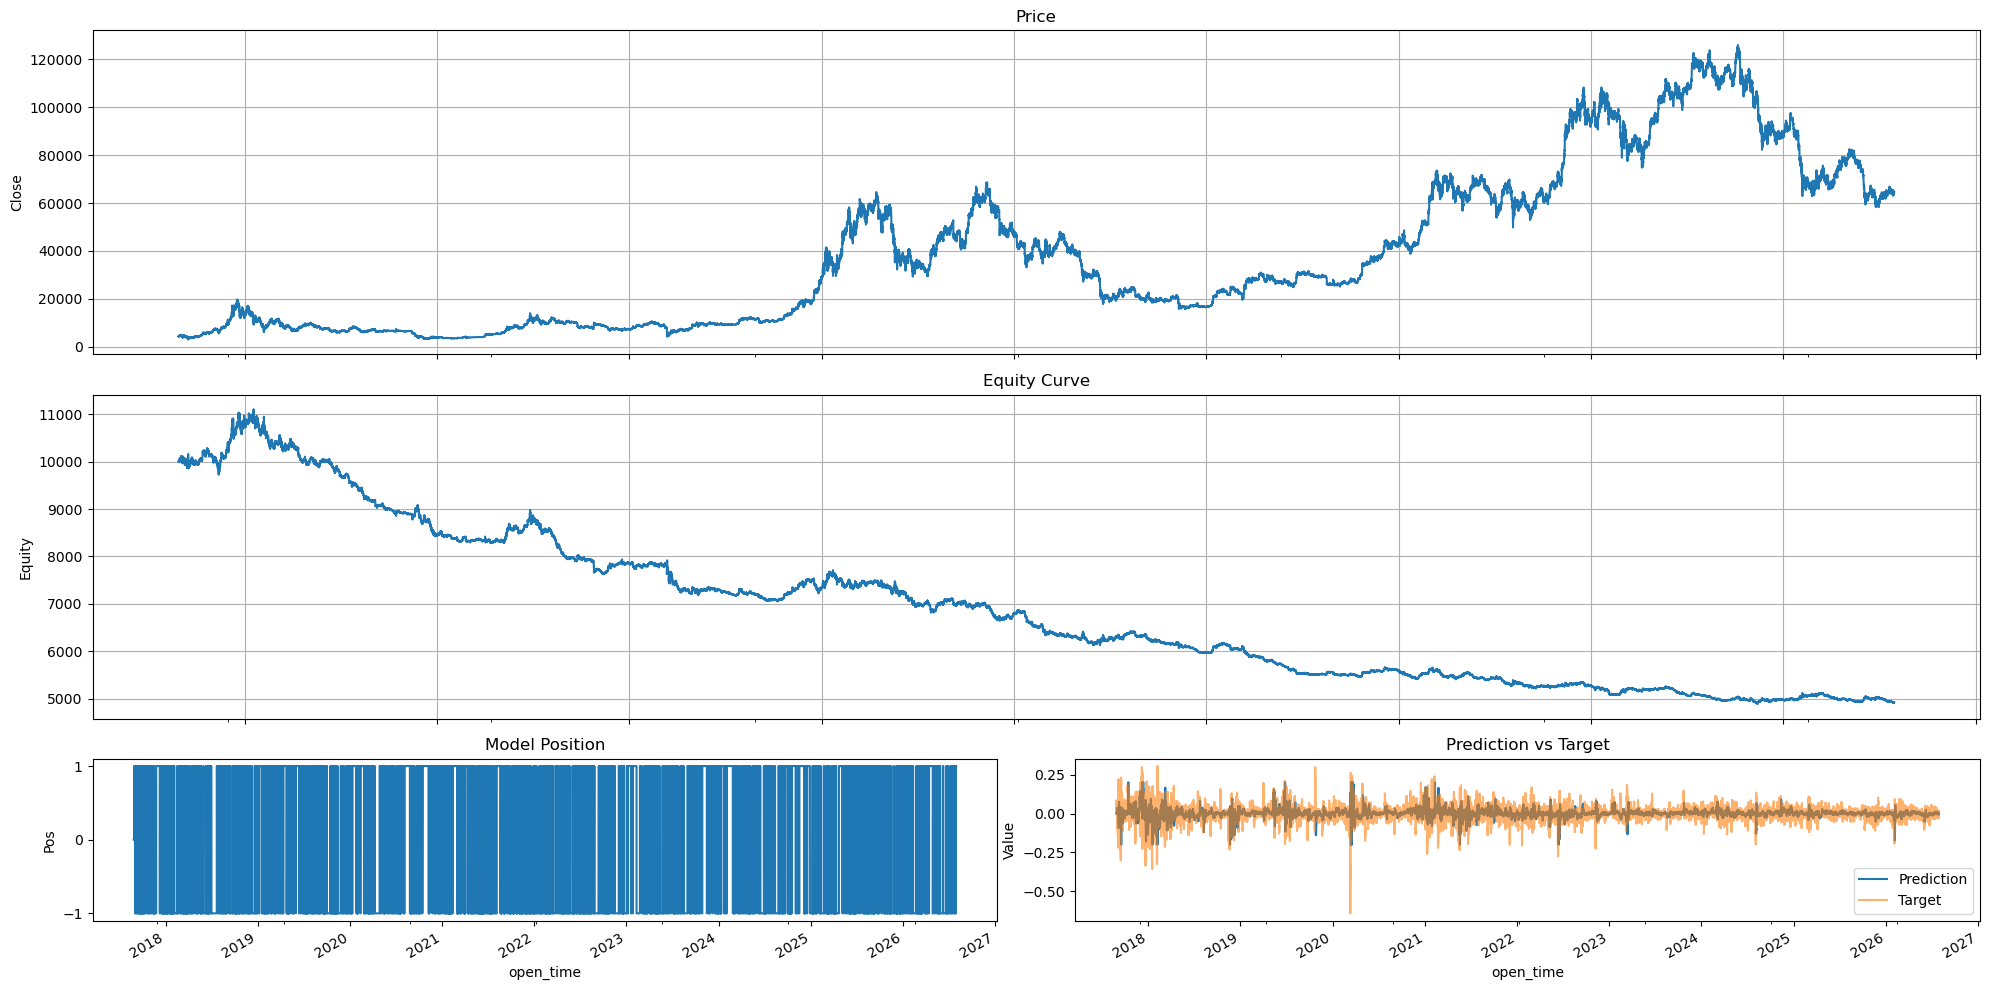

In [72]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1])

ax_price = fig.add_subplot(gs[0, :])
ax_equity = fig.add_subplot(gs[1, :], sharex=ax_price)
ax_pos = fig.add_subplot(gs[2, 0], sharex=ax_price)
ax_pred = fig.add_subplot(gs[2, 1], sharex=ax_price)

final_result["close"].plot(ax=ax_price, title="Price", grid=True)
final_result["equity"].plot(ax=ax_equity, title="Equity Curve", grid=True)
final_result["position"].plot(ax=ax_pos, title="Model Position", drawstyle="steps-post")

final_result["prediction"].plot(ax=ax_pred, label="Prediction", title="Prediction vs Target")
final_result[target_col].plot(ax=ax_pred, label="Target", alpha=0.6)

ax_price.set_ylabel("Close")
ax_equity.set_ylabel("Equity")
ax_pos.set_ylabel("Pos")
ax_pred.set_ylabel("Value")

ax_pos.set_yticks([-1, 0, 1])
ax_pred.legend()

plt.tight_layout()
plt.show()

# Research Summary Table

In [73]:
summary = pd.DataFrame({
    "baseline_pred": pd.Series(baseline_pred_metrics),
    "final_pred": pd.Series(final_pred_metrics),
})

summary

,baseline_pred,final_pred
mse,0.002589,0.002665
mae,0.033717,0.034282
corr,-0.030024,-0.027569
direction_acc,0.498623,0.500013


# Trading Summary Table

In [74]:
trading_summary = pd.DataFrame({
    "baseline_trading": pd.Series(baseline_trading_metrics),
    "final_trading": pd.Series(final_trading_metrics),
})

trading_summary

,baseline_trading,final_trading
final_equity,4461.858155,4926.165128
total_return,-0.553814,-0.507383
sharpe,-1.257088,-1.067149
max_drawdown,-0.602816,-0.559208
trade_count,4883.000000,2681.000000
long_count,1335.000000,1341.000000
short_count,1348.000000,1340.000000
flat_count,2200.000000,0.000000
avg_bar_return,-0.000010,-0.000009


# Final Feature Importance

In [79]:
X_final = df_final[feature_cols_final].astype(float).to_numpy()
y_final = df_final[target_col_final].astype(float).to_numpy()

# Train a fresh linear model using the same online-learning approach
importance_model = LinearRegressionModel(
    n_features=X_final.shape[1],
    lr=float(best_hyper_param["LR"]),
    model_l2=float(best_hyper_param["MODEL_L2"])
)

for x_i, y_i in zip(X_final, y_final):
    importance_model.update(x_i, y_i)

# Signed and absolute feature importance
feature_importance = pd.DataFrame({
    "feature": feature_cols_final,
    "coefficient": importance_model.w,
    "importance": np.abs(importance_model.w)
}).sort_values("importance", ascending=False)

display(feature_importance)

,feature,coefficient,importance
5,ret_250,-0.000830,0.000830
4,ret_225,-0.000733,0.000733
3,ret_200,-0.000469,0.000469
2,ret_175,-0.000392,0.000392
1,ret_150,-0.000387,0.000387
0,ret_125,-0.000315,0.000315
9,volatility_200,0.000019,0.000019
10,volatility_225,0.000019,0.000019
8,volatility_175,0.000018,0.000018
11,volatility_250,0.000017,0.000017
